In [1]:

from google.colab import files
import pandas as pd
import io

print(" Please upload your preprocessed wildfire dataset (.csv)")
uploaded = files.upload()

if not uploaded:
    raise ValueError(" No file uploaded. Please rerun and upload a CSV file.")

CSV_PATH = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[CSV_PATH]))

print(f" Uploaded File: {CSV_PATH}")
print(" Dataset Loaded — Shape:", df.shape)

# --- User Settings ---
TARGET_COL = "area"   # target variable for regression
TEST_SIZE = 0.2
RANDOM_STATE = 42
CATEGORICAL_COLS = []    # e.g., ['region','month']
RUN_TUNING = True        # set False to skip tuning

df.head()


 Please upload your preprocessed wildfire dataset (.csv)


Saving final_processed_pipeline.csv to final_processed_pipeline.csv
 Uploaded File: final_processed_pipeline.csv
 Dataset Loaded — Shape: (220, 6)


,DC,temp,DMC,RH,ISI,area
0,0.607908,0.354497,0.000000,0.327273,0.159664,0.0
1,0.653316,0.174603,0.048368,0.327273,0.159664,0.0
2,0.145918,0.576720,0.290793,0.254545,0.831933,0.0
3,0.165306,0.677249,0.311772,0.218182,0.310924,0.0
4,0.667857,0.095238,0.548368,0.872727,0.184874,0.0


 Please upload your preprocessed wildfire dataset (.csv) again to ensure the data is loaded in this cell.


Saving final_processed_pipeline.csv to final_processed_pipeline (1).csv
 Dataset loaded successfully: (220, 6)


,DC,temp,DMC,RH,ISI,area
0,0.607908,0.354497,0.000000,0.327273,0.159664,0.0
1,0.653316,0.174603,0.048368,0.327273,0.159664,0.0
2,0.145918,0.576720,0.290793,0.254545,0.831933,0.0
3,0.165306,0.677249,0.311772,0.218182,0.310924,0.0
4,0.667857,0.095238,0.548368,0.872727,0.184874,0.0



 Basic Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DC      220 non-null    float64
 1   temp    220 non-null    float64
 2   DMC     220 non-null    float64
 3   RH      220 non-null    float64
 4   ISI     220 non-null    float64
 5   area    220 non-null    float64
dtypes: float64(6)
memory usage: 10.4 KB
None


,count,mean,std,min,25%,50%,75%,max
DC,220.0,0.606320,0.223467,0.0,0.493367,0.652296,0.759694,1.00
temp,220.0,0.490308,0.195423,0.0,0.353175,0.481481,0.619048,1.00
DMC,220.0,0.480160,0.203305,0.0,0.358392,0.460373,0.598048,1.00
RH,220.0,0.473471,0.215364,0.0,0.327273,0.454545,0.600000,1.00
ISI,220.0,0.376547,0.226324,0.0,0.193277,0.336134,0.487395,1.00
area,220.0,1.220864,1.920072,0.0,0.000000,0.000000,1.787500,7.21


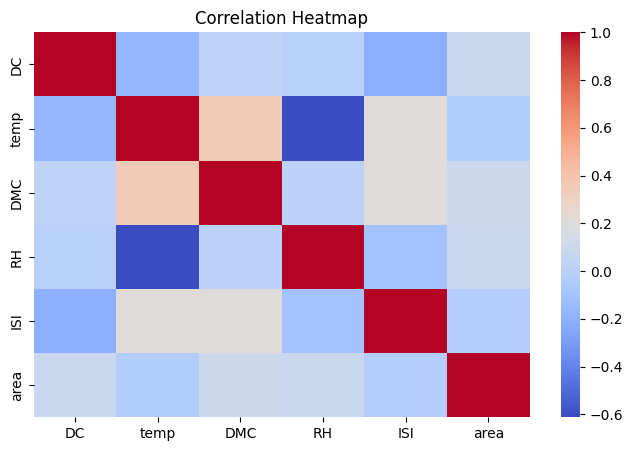


Train shape: (176, 5) | Test shape: (44, 5)


In [2]:
#  Minimal Preparation After Upload (for Preprocessed Dataset)
import seaborn as sns, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import io
from google.colab import files

# Re-upload the file to ensure df is defined in this cell's scope
print(" Please upload your preprocessed wildfire dataset (.csv) again to ensure the data is loaded in this cell.")
uploaded = files.upload()

if not uploaded:
    raise ValueError(" No file uploaded. Please rerun and upload a CSV file.")

CSV_PATH = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[CSV_PATH]))

print(" Dataset loaded successfully:", df.shape)
display(df.head())

# 1️ Quick EDA verification
print("\n Basic Dataset Info:")
print(df.info())
display(df.describe().T)

plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

# 2️Feature / Target split
TARGET_COL = "area"  # target variable for wildfire prediction
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# 3️ Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f"\nTrain shape: {X_train.shape} | Test shape: {X_test.shape}")

# 4️ Common Evaluation Function
def evaluate_model(y_true, y_pred, name="Model"):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"\n{name} Results:")
    print(f"R²  = {r2:.4f}")
    print(f"MAE = {mae:.4f}")
    print(f"RMSE = {rmse:.4f}")
    return r2, mae, rmse

## 1. Imports

Gradient Boosting Regressor

In [3]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np, seaborn as sns, matplotlib.pyplot as pl

In [4]:
# Step 1 – Create model
gbr = GradientBoostingRegressor(random_state=42)

In [5]:
# Step 2 - Train model

gbr.fit(X_train,y_train)

GradientBoostingRegressor(random_state=42)

In [6]:
# Step 3 – Predict
y_pred_gbr=gbr.predict(X_test)

In [7]:
# Step 4 – Evaluate
r2_gbr = r2_score(y_test, y_pred_gbr)
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))

print(" Gradient Boosting Regressor (Base Model):")
print(f"R² = {r2_gbr:.4f}, MAE = {mae_gbr:.4f}, RMSE = {rmse_gbr:.4f}")

 Gradient Boosting Regressor (Base Model):
R² = -0.2853, MAE = 1.6457, RMSE = 2.3697


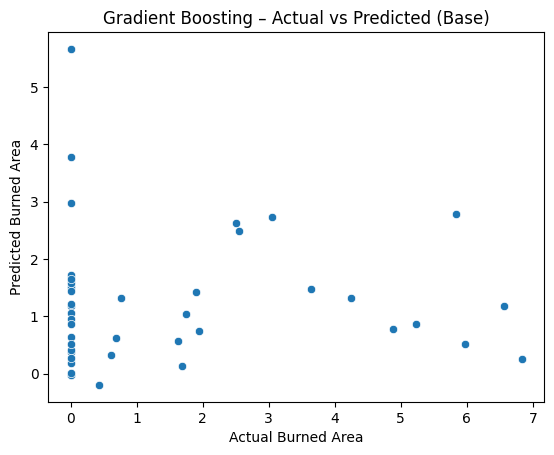

In [9]:
# Step 5 – Visualization
sns.scatterplot(x=y_test, y=y_pred_gbr)
plt.xlabel("Actual Burned Area")
plt.ylabel("Predicted Burned Area")
plt.title("Gradient Boosting – Actual vs Predicted (Base)")
plt.show()

Hyperparameter Tuning (Experiment 1 & 2)

In [10]:
from sklearn.model_selection import GridSearchCV

# --- Experiment 1 ---
param_grid_gbr1 = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [3, 5, 7]
}
grid_gbr1 = GridSearchCV(GradientBoostingRegressor(random_state=42),
                         param_grid=param_grid_gbr1, cv=5,
                         scoring="r2", n_jobs=-1)
grid_gbr1.fit(X_train, y_train)
print(" Best Params (Exp 1):", grid_gbr1.best_params_)
print("Best CV R²:", grid_gbr1.best_score_)

# --- Experiment 2 (fine-tuning around best) ---
param_grid_gbr2 = {
    "n_estimators": [150, 250, 350],
    "learning_rate": [0.05, 0.08, 0.1],
    "subsample": [0.8, 1.0],
    "max_depth": [3, 4, 5]
}
grid_gbr2 = GridSearchCV(GradientBoostingRegressor(random_state=42),
                         param_grid=param_grid_gbr2, cv=10,
                         scoring="r2", n_jobs=-1)
grid_gbr2.fit(X_train, y_train)
print(" Best Params (Exp 2):", grid_gbr2.best_params_)
print("Best CV R²:", grid_gbr2.best_score_)


 Best Params (Exp 1): {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
Best CV R²: -0.811009514497505
 Best Params (Exp 2): {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150, 'subsample': 1.0}
Best CV R²: -0.7974839518710445


Evaluate Tuned Models & Compare

,Model,R²,MAE,RMSE
0,Base GBR,-0.285256,1.645740,2.369665
1,Tuned Grid 1,-0.426819,1.755009,2.496760
2,Tuned Grid 2,-0.262747,1.661096,2.348824


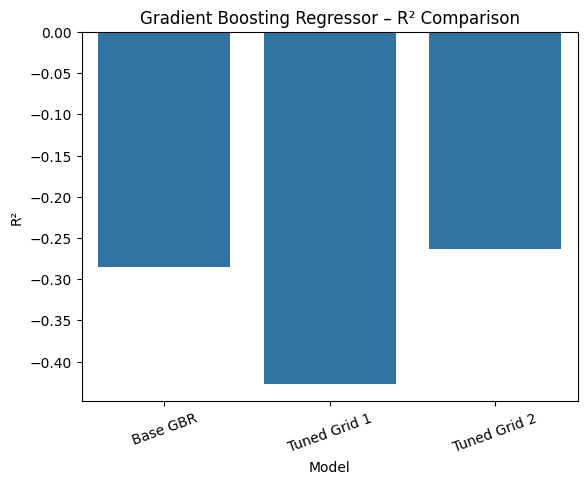

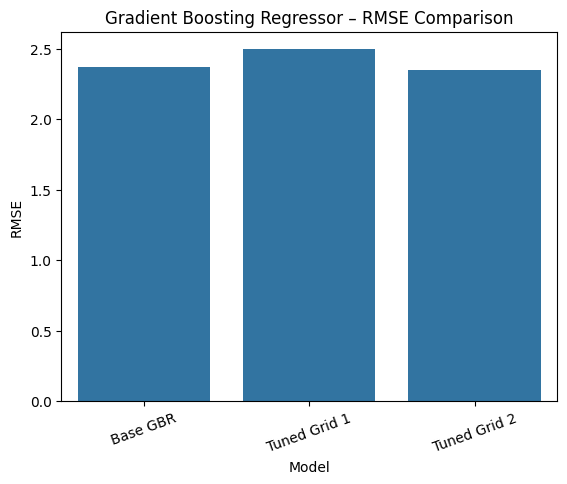

In [12]:
from math import sqrt
import pandas as pd

# Grid 1
best_gbr1 = grid_gbr1.best_estimator_
pred1 = best_gbr1.predict(X_test)
r2_1 = r2_score(y_test, pred1)
mae_1 = mean_absolute_error(y_test, pred1)
rmse_1 = sqrt(mean_squared_error(y_test, pred1))

# Grid 2
best_gbr2 = grid_gbr2.best_estimator_
pred2 = best_gbr2.predict(X_test)
r2_2 = r2_score(y_test, pred2)
mae_2 = mean_absolute_error(y_test, pred2)
rmse_2 = sqrt(mean_squared_error(y_test, pred2))

# Summary table
comparison = pd.DataFrame({
    "Model": ["Base GBR", "Tuned Grid 1", "Tuned Grid 2"],
    "R²": [r2_gbr, r2_1, r2_2],
    "MAE": [mae_gbr, mae_1, mae_2],
    "RMSE": [rmse_gbr, rmse_1, rmse_2]
})
display(comparison)

# Visualization
sns.barplot(x="Model", y="R²", data=comparison)
plt.title("Gradient Boosting Regressor – R² Comparison")
plt.xticks(rotation=20)
plt.show()

sns.barplot(x="Model", y="RMSE", data=comparison)
plt.title("Gradient Boosting Regressor – RMSE Comparison")
plt.xticks(rotation=20)
plt.show()
